In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [3]:
file_path = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v1/runs/0/edm4hep.root"
event = EDM4hepEvent(file_path, event_index=0, detector_params=detector_params)

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v1/runs/0/edm4hep.root...
  Loaded 754176 particles.
  Loaded 186282 tracker hits.
  Loaded 1178204 calo hits and 5395479 contributions.


In [4]:
event

<EDM4hepEvent file='/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v1/runs/0/edm4hep.root' index=0 particles=754176 track_hits=186282 calo_hits=1178204>

In [5]:
particles = event.get_particles_df()

In [6]:
hits = event.get_tracker_hits_df()

In [7]:
calo_hits = event.get_calo_contributions_df()

In [37]:
daughters = event.get_daughters_df()

In [20]:
particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.007208,6500.000000,6499.061730,0,False,True,True,False
1,2,61,0,0.666667,6.578353,0.000000,0.002819,0.006634,-10.213689,0.000000e+00,...,0.000000,0.007208,0.007208,1571.963510,1571.963510,0,False,True,True,False
2,2101,63,0,0.333333,6.578353,0.579330,0.002819,0.006634,-10.213689,0.000000e+00,...,0.000000,0.007208,0.007208,4928.036468,4927.457138,0,False,True,True,False
3,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.007208,6500.000000,6499.061730,0,False,True,True,False
4,21,61,0,0.000000,6.578353,0.000000,0.002819,0.006634,-10.213689,-1.893266e-29,...,3.141593,0.007208,0.007208,414.488101,414.488101,0,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754171,-11,0,1426063360,1.000000,12.033926,0.000511,1310.614391,-4.754008,968.181801,1.066894e-02,...,0.013146,1310.623013,1313.361465,0.013297,0.012786,28,True,False,False,False
754172,11,0,1426063360,-1.000000,12.097413,0.000511,1327.492548,-5.016023,977.276286,8.801583e-03,...,0.014288,1327.502025,1328.869091,0.010733,0.010222,1,True,False,False,False
754173,-11,0,1426063360,1.000000,12.097413,0.000511,1327.492548,-5.016023,977.276286,3.492928e-03,...,-0.063082,1327.502025,1328.607725,0.004060,0.003549,1,True,False,False,False
754174,11,0,1426063360,-1.000000,11.990582,0.000511,1301.021763,-5.170045,959.224385,4.709631e-02,...,-0.033381,1301.032036,1317.323545,0.055583,0.055072,12,True,False,False,False


In [9]:
hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,251099525873926,0.197362,1.143237,0,31.948784,8.387982,304.103188,0.141615,0.038574,1.287007,0.000508,73892,PixelBarrelReadout,33.031546,305.891863,0.256750,0.108195,2.915988,0.146775
1,268833311557894,-0.005791,0.924997,0,-25.866845,-19.192489,244.571263,-0.547206,-0.406811,4.962536,0.000319,73893,PixelBarrelReadout,32.209397,246.683092,-2.503249,0.130944,2.724704,0.681857
2,278106162727430,0.016830,0.952562,0,-26.605453,-19.741443,251.273490,-0.546516,-0.406862,4.962300,0.000287,73893,PixelBarrelReadout,33.129665,253.448104,-2.503226,0.131091,2.723578,0.681334
3,44325371974422,0.866307,0.917362,0,-54.295885,-40.679673,503.479616,-0.540992,-0.409832,4.922761,0.000465,73893,PixelBarrelReadout,67.844520,508.030120,-2.498590,0.133944,2.701981,0.678700
4,28311049470470,0.577116,1.615324,0,26.146014,20.102006,419.308360,0.158378,0.122818,2.495183,0.000468,73889,PixelBarrelReadout,32.980369,420.603383,0.655448,0.078493,3.237384,0.200419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186277,893353201966,14.977505,0.282460,0,1030.933897,103.334053,1904.500000,0.108025,0.011924,0.208007,0.000090,768,LongStripEndcapReadout,1036.099718,2168.091990,0.099900,0.498246,1.368816,0.108681
186278,949188825390,14.999388,0.282502,0,1033.520388,103.618448,1909.500000,0.107800,0.012603,0.206079,0.000121,768,LongStripEndcapReadout,1038.701678,2173.727542,0.099924,0.498198,1.368916,0.108534
186279,231929446494,8274.898438,0.273571,0,385.251314,-648.494860,2990.429615,-0.000098,-0.000121,0.000226,0.000239,753004,LongStripEndcapReadout,754.297129,3084.093618,-1.034749,0.247083,2.086072,0.000156
186280,17020955586830,12.237954,0.320054,0,1051.736719,-119.768064,1304.500000,0.841405,-0.090375,1.059283,0.000088,717,LongStripEndcapReadout,1058.534135,1679.944869,-0.113388,0.681683,1.036529,0.846244


In [10]:
calo_hits.columns

Index(['PDG', 'energy', 'time', 'step_x', 'step_y', 'step_z', 'particle_id',
       'cellID', 'x', 'y', 'z', 'detector'],
      dtype='object')

In [11]:
calo_hits['r'] = np.sqrt(calo_hits['x']**2 + calo_hits['y']**2)

## Plotting

In [12]:
tracker_reco_particles = particles[particles.index.isin(hits.particle_id)]

In [13]:
tracker_reco_particles.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r', 'energy',
       'kinetic_energy', 'num_hits', 'created_in_simulation',
       'created_inside_tracker', 'ended_inside_tracker', 'backscatter'],
      dtype='object')

<Axes: xlabel='num_hits', ylabel='Count'>

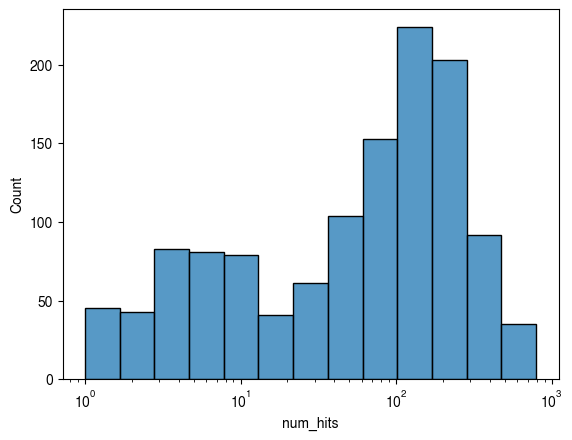

In [71]:
sns.histplot(tracker_selected_particles.num_hits, log_scale=True)

<Axes: >

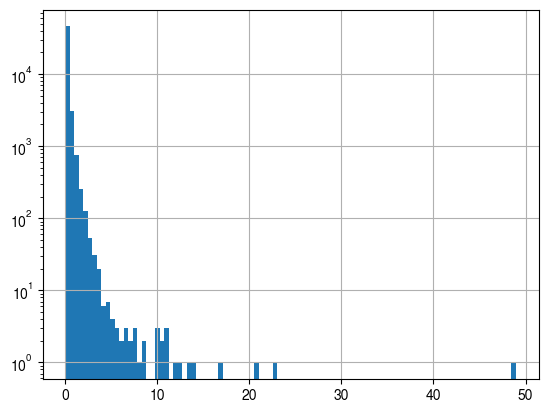

In [15]:
tracker_reco_particles.pt.hist(bins=100, log=True)
# log x

In [16]:
kinematic_selections = [
    "pt > 1",
]

tracker_selected_particles = tracker_reco_particles.query(" & ".join(kinematic_selections))

In [17]:
tracker_selected_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
81,-321,1,16777216,-1.0,6.578353,0.493680,0.002819,0.006634,-10.213689,-2.667885,...,-2.738253,0.007208,1448.757628,6.656601,6.162921,618,False,True,False,False
88,-211,1,16777216,-1.0,6.578353,0.139570,0.002819,0.006634,-10.213689,-5.966103,...,-2.776760,0.007208,1256.168261,15.169712,15.030142,101,False,True,False,False
91,-321,1,16777216,-1.0,6.578353,0.493680,0.002819,0.006634,-10.213689,-4.256699,...,-2.846305,0.007208,1378.184766,13.326840,12.833160,122,False,True,False,False
266,-321,1,16777216,-1.0,6.578353,0.493680,0.002819,0.006634,-10.213689,0.547169,...,1.149360,0.007208,1410.246288,1.709052,1.215372,64,False,True,False,False
271,321,1,16777216,1.0,6.578353,0.493680,0.002819,0.006634,-10.213689,0.491119,...,-1.286300,0.007208,1688.367915,2.937989,2.444309,165,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747986,211,0,1157627904,1.0,7.070652,0.139570,54.894736,-117.757373,-80.202204,1.836918,...,-1.133372,129.923943,1323.472275,4.803174,4.663604,152,True,True,False,False
748090,-211,0,1157627904,-1.0,11.556531,0.139570,595.981738,-1140.131478,-765.815539,0.730755,...,-1.154361,1286.504575,1337.022962,2.010569,1.870999,227,True,False,False,False
748561,11,0,1157627904,-1.0,9.545419,0.000511,375.636531,-724.255736,-364.534440,4.997882,...,-1.092484,815.873259,1273.124101,11.836983,11.836472,19,True,True,False,False
748562,-11,0,1157627904,1.0,9.545419,0.000511,375.636531,-724.255736,-364.534440,2.586430,...,-1.092555,815.873259,1276.341298,6.126489,6.125978,24,True,True,False,False


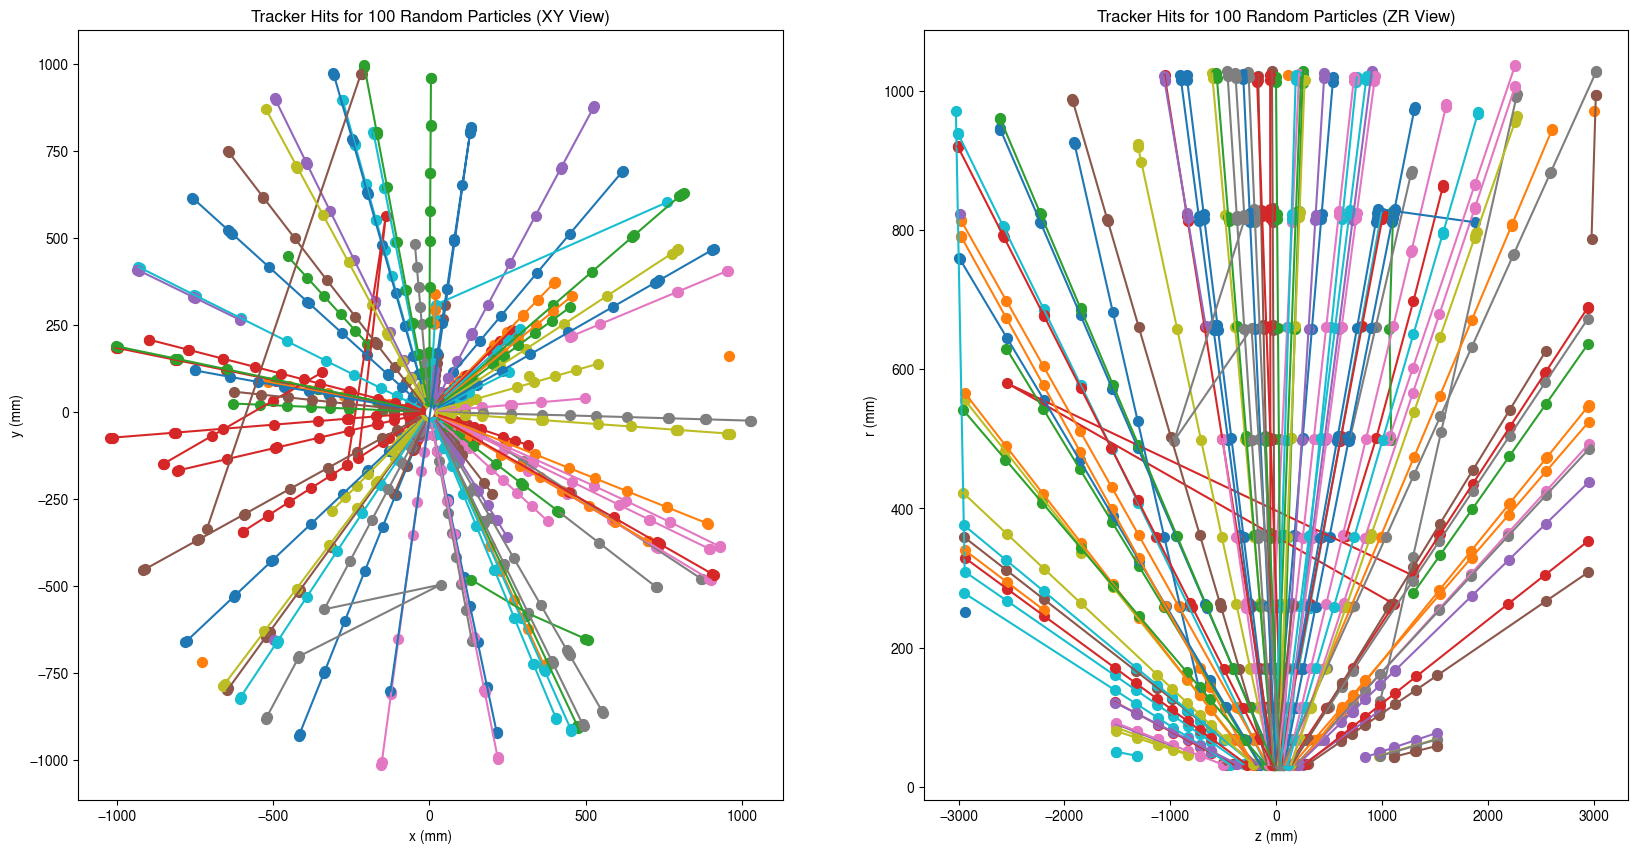

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Select 50 random particles
sample_particles = tracker_selected_particles.sample(100, random_state=42)

# Select all hits for the selected particles
sample_hits = hits[hits['particle_id'].isin(sample_particles.index)]

# Plot the hits, colored by particle id
for particle_id in sample_particles.index:
    particle_hits = sample_hits[sample_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

<Axes: xlabel='num_hits', ylabel='Count'>

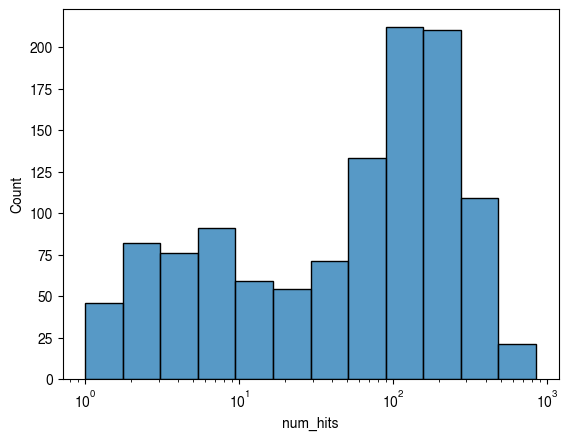

In [ ]:
sns.histplot(tracker_selected_particles.num_hits, log_scale=True)

In [23]:
sample_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
54147,2212,1,16777216,1.0,-0.110716,0.938270,-0.032132,0.003545,-25.023246,-0.479518,...,-1.999864,0.032327,1388.382453,1.614788,0.676518,91,False,True,False,False
445522,11,0,1157627904,-1.0,1.797865,0.000511,-726.566737,-715.089959,112.177910,-0.784408,...,-2.364328,1019.437528,1269.711967,1.109272,1.108761,7,True,True,False,False
45061,211,1,16777216,1.0,2.116222,0.139570,0.014219,-0.012349,41.280644,1.251946,...,0.658477,0.018833,1373.588295,1.622228,1.482658,53,False,True,False,False
29032,-211,1,16777216,-1.0,3.989472,0.139570,0.010815,0.009418,-16.303890,-0.928990,...,-2.611445,0.014341,755.323504,4.775884,4.636314,91,False,True,False,False
50659,211,1,16777216,1.0,-6.560731,0.139570,0.008753,0.017617,37.534889,-0.669540,...,2.079937,0.019672,1651.967270,1.799985,1.660415,119,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54143,211,1,0,1.0,-0.110716,0.139570,-0.032132,0.003545,-25.023246,-0.643824,...,-2.018150,0.032327,293.248522,1.817144,1.677574,5,False,True,True,False
722030,-211,0,1157627904,-1.0,9.593019,0.139570,341.175001,175.206844,807.119772,2.070054,...,0.361593,383.533336,1342.281430,5.374779,5.235209,62,True,True,False,False
18350,-321,1,16777216,-1.0,-3.068196,0.493680,-0.009931,-0.007425,47.482617,-0.519986,...,-2.106556,0.012400,1389.295745,1.211316,0.717636,218,False,True,False,False
43593,-211,1,16777216,-1.0,-7.870784,0.139570,0.004731,0.003390,7.537527,-1.632963,...,-2.405541,0.005821,521.256182,15.614326,15.474756,299,False,True,False,False


In [24]:
sample_hits.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'detector', 'r', 'R', 'phi', 'theta',
       'eta', 'pt'],
      dtype='object')

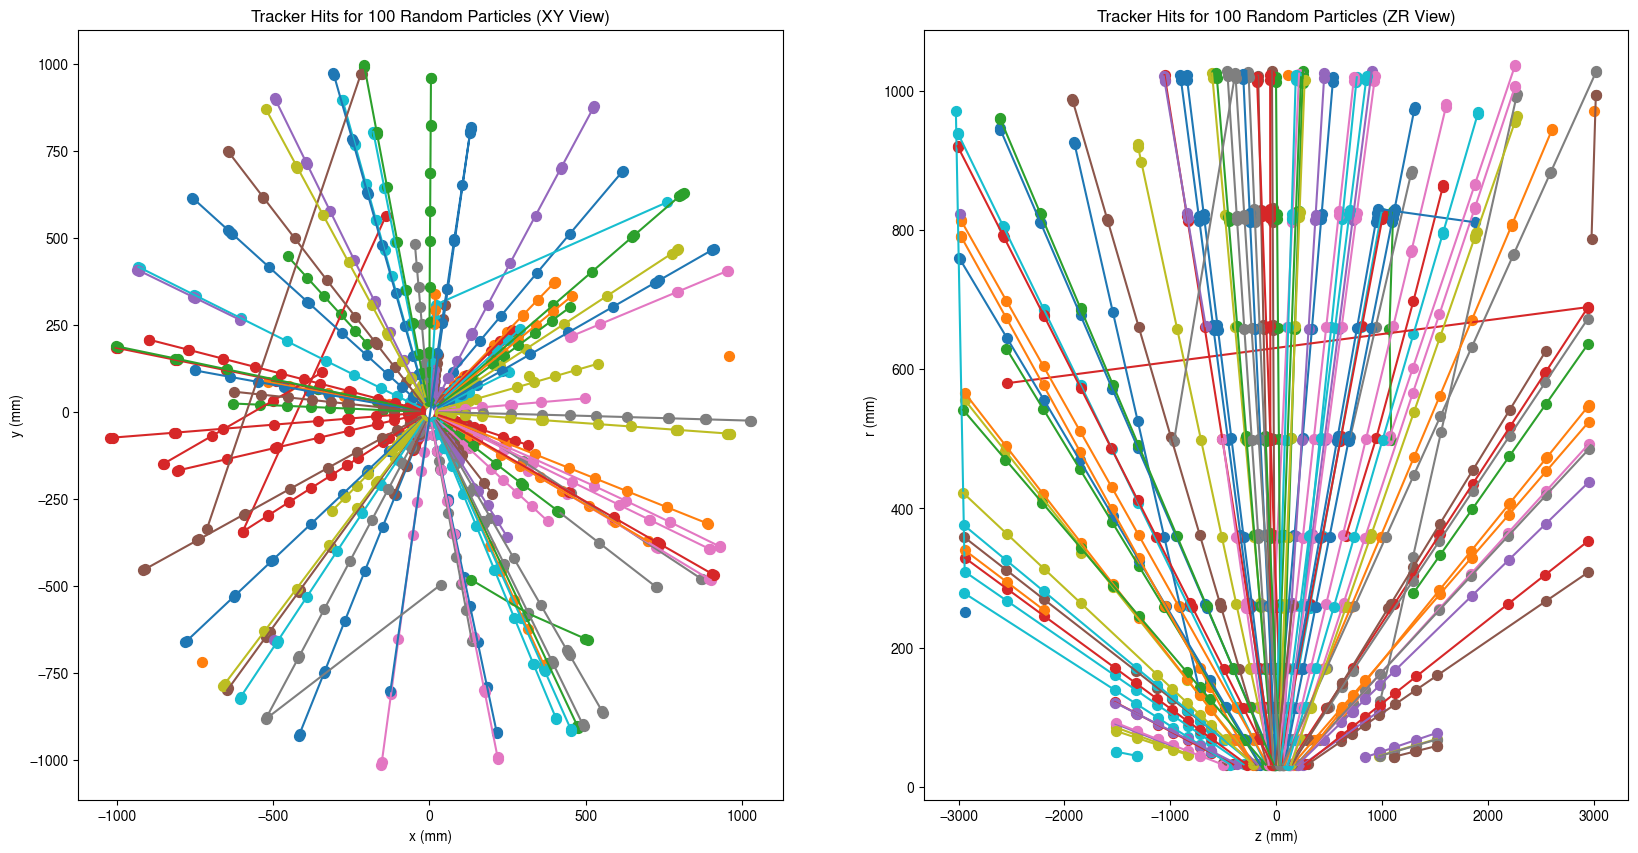

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Select 50 random particles
sample_particles = tracker_selected_particles.sample(100, random_state=42)

# Select all hits for the selected particles
sample_hits = hits[hits['particle_id'].isin(sample_particles.index)]

# Order sample_hits by time
sample_hits = sample_hits.sort_values(by='time')

# Plot the hits, colored by particle id
for particle_id in sample_particles.index:
    particle_hits = sample_hits[sample_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

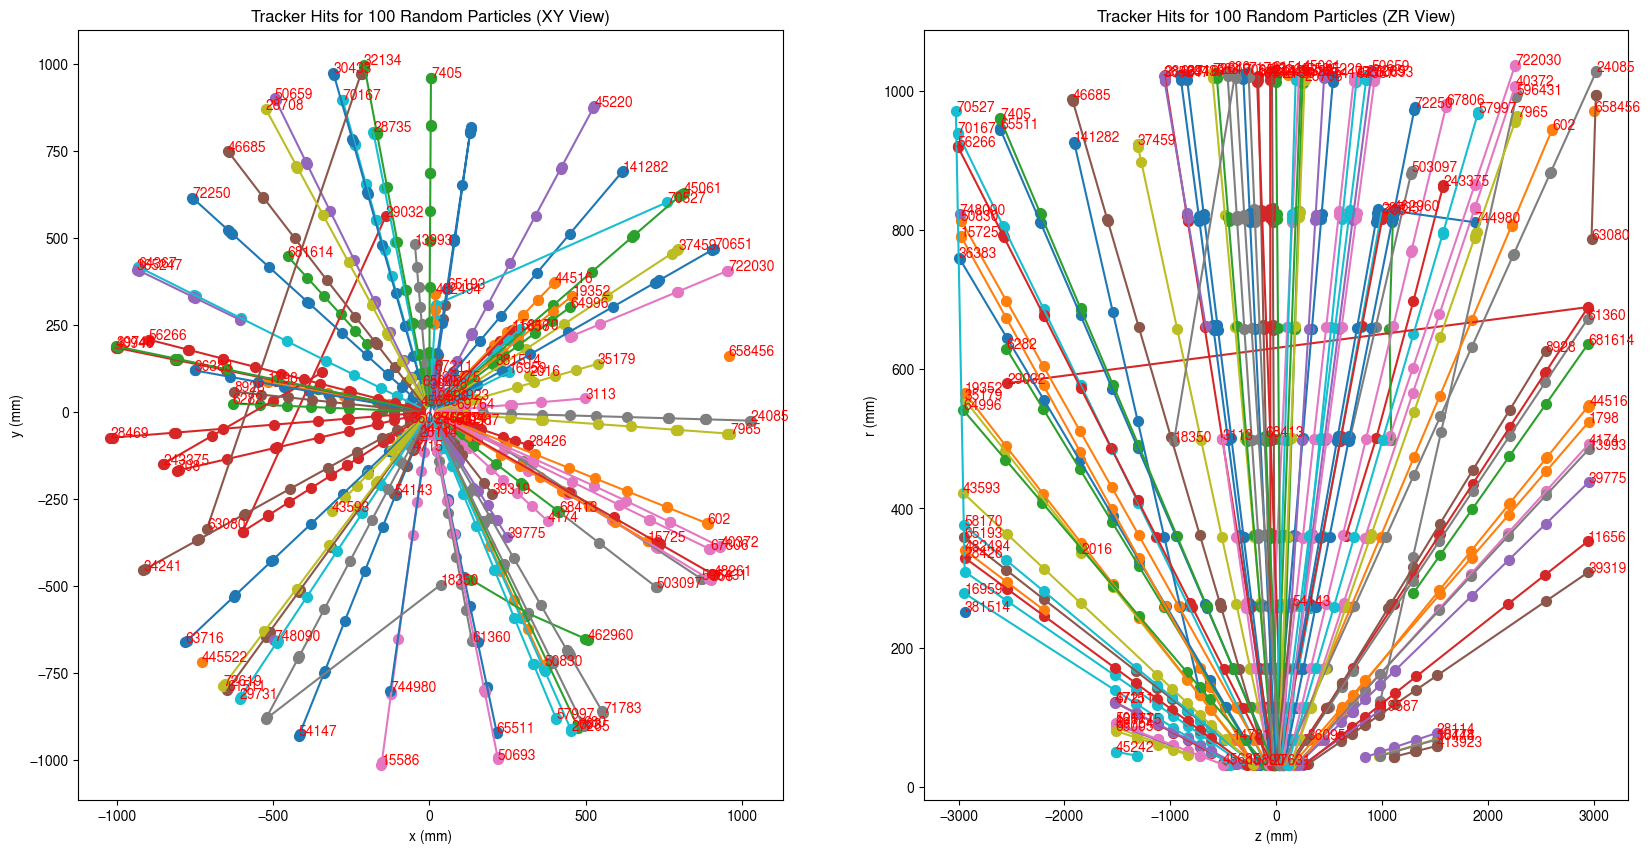

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Select 50 random particles
sample_particles = tracker_selected_particles.sample(100, random_state=42)

# Select all hits for the selected particles
sample_hits = hits[hits['particle_id'].isin(sample_particles.index)]

# Order sample_hits by time
sample_hits = sample_hits.sort_values(by='time')

# Plot the hits, colored by particle id
for particle_id in sample_particles.index:
    particle_hits = sample_hits[sample_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

    # Next to last hit, add the particle ID
    ax1.text(particle_hits.x.iloc[-1], particle_hits.y.iloc[-1], particle_id, color='red')
    ax2.text(particle_hits.z.iloc[-1], particle_hits.r.iloc[-1], particle_id, color='red')

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

## Zany 18250

In [56]:
zany_track_id = 18350
zany_hits = hits[hits.particle_id == zany_track_id].sort_values(by='time').reset_index(drop=True)
zany_calo_hits = calo_hits[calo_hits.particle_id == zany_track_id].sort_values(by='time').reset_index(drop=True)
zany_particle = particles.iloc[zany_track_id]

In [57]:
zany_particle

PDG                              -321
generatorStatus                     1
simulatorStatus              16777216
charge                           -1.0
time                        -3.068196
mass                          0.49368
vx                          -0.009931
vy                          -0.007425
vz                          47.482617
px                          -0.519986
py                          -0.875867
pz                          -0.431322
endpoint_x                -699.376615
endpoint_y                -1200.42285
endpoint_z                -547.399645
parents_begin                   53947
parents_end                     53948
daughters_begin                 84550
daughters_end                   84562
pt                           1.018592
p                             1.10615
eta                         -0.411718
phi                         -2.106556
vr                             0.0124
endpoint_r                1389.295745
energy                       1.211316
kinetic_ener

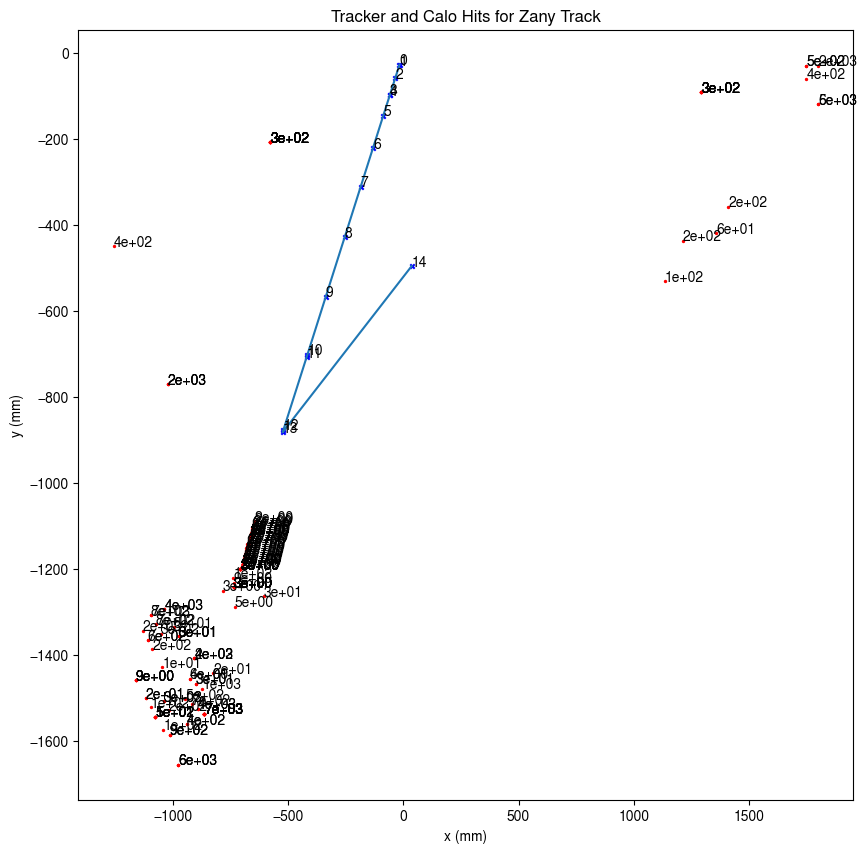

In [58]:
plt.figure(figsize=(10, 10))

# Plot tracker hits
plt.scatter(zany_hits.x, zany_hits.y, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.x, hit.y, str(i), fontsize=10)
plt.plot(zany_hits.x, zany_hits.y)

# Plot calo hits
plt.scatter(zany_calo_hits.x, zany_calo_hits.y, s=2, color='red')

for i, hit in zany_calo_hits.iterrows():
    # Only show 1 significant figure of the time
    plt.text(hit.x, hit.y, f"{hit.time:.0e}", fontsize=10)

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

In [59]:
zany_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,278179210529286,-2.940174,0.136835,0,-16.458817,-27.704432,33.849579,-0.520446,-0.875713,-0.430202,0.000042,18350,PixelBarrelReadout,32.224652,46.735663,-2.106856,0.760811,0.916584,1.018694
1,277762598701830,-2.936709,0.140525,0,-16.904211,-28.454104,33.481452,-0.520345,-0.875699,-0.430230,0.000045,18350,PixelBarrelReadout,33.096652,47.078615,-2.106857,0.779619,0.889571,1.018630
2,257493171639574,-2.798860,0.136038,0,-34.659882,-58.328586,18.779289,-0.520024,-0.874698,-0.430596,0.000036,18350,PixelBarrelReadout,67.849328,70.400234,-2.106953,1.300777,0.273362,1.017606
3,48999654892070,-2.617612,0.135961,0,-58.039404,-97.563918,-0.578370,-0.520483,-0.873395,-0.430784,0.000035,18350,PixelBarrelReadout,113.522203,113.523677,-2.107447,1.575891,-0.005095,1.016721
4,48170357105446,-2.611386,0.137827,0,-58.841950,-98.911260,-1.242574,-0.520071,-0.873564,-0.430827,0.000045,18350,PixelBarrelReadout,115.090453,115.097161,-2.107455,1.581592,-0.010796,1.016655
5,15873511666742,-2.391558,0.136998,0,-87.172886,-146.498239,-24.731585,-0.519729,-0.872730,-0.430874,0.000032,18350,PixelBarrelReadout,170.472421,172.257068,-2.107564,1.714868,-0.144573,1.015763
6,1652694826162953,-2.043723,0.218145,0,-131.831890,-221.787956,-61.959657,-0.517213,-0.870774,-0.430944,0.000079,18350,ShortStripBarrelReadout,258.010745,265.346083,-2.107092,1.806477,-0.237893,1.012797
7,88480621864217,-1.632704,0.220771,0,-184.671499,-310.729043,-105.969044,-0.515927,-0.870446,-0.430905,0.000060,18350,ShortStripBarrelReadout,361.463830,376.676969,-2.107027,1.855972,-0.289122,1.011858
8,1864419533927465,-1.085697,0.219283,0,-254.823916,-429.162597,-164.566297,-0.516258,-0.870399,-0.428355,0.000054,18350,ShortStripBarrelReadout,499.114979,525.545268,-2.106622,1.889288,-0.324017,1.011986
9,71546961081680953,-0.451437,0.219283,0,-336.298003,-566.550151,-232.165658,-0.515335,-0.870030,-0.427938,0.000098,18350,ShortStripBarrelReadout,658.844003,698.553013,-2.106489,1.909593,-0.345470,1.011199


In [60]:
zany_calo_hits

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector,r
0,0,0.000176,1.953360,0.0,0.0,0.0,18350,221576,-644.185242,-1088.757690,-484.500000,ECalBarrelCollection,1265.056519
1,0,0.000149,1.973707,0.0,0.0,0.0,18350,221577,-646.117798,-1093.423340,-484.500000,ECalBarrelCollection,1270.056274
2,0,0.000157,1.994130,0.0,0.0,0.0,18350,221578,-648.050354,-1098.088867,-489.600006,ECalBarrelCollection,1275.056274
3,0,0.000172,2.014715,0.0,0.0,0.0,18350,221579,-654.694641,-1100.802856,-489.600006,ECalBarrelCollection,1280.777832
4,0,0.000170,2.035332,0.0,0.0,0.0,18350,221580,-656.627197,-1105.468384,-494.700012,ECalBarrelCollection,1285.775879
...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,0,0.000011,7497.374512,0.0,0.0,0.0,18350,50226,-863.519348,-1535.963745,-120.000000,HCalBarrelCollection,1762.058594
199,0,0.000008,7497.374512,0.0,0.0,0.0,18350,50226,-863.519348,-1535.963745,-120.000000,HCalBarrelCollection,1762.058594
200,0,0.000014,7497.374512,0.0,0.0,0.0,18350,50226,-863.519348,-1535.963745,-120.000000,HCalBarrelCollection,1762.058594
201,0,0.000030,7497.375000,0.0,0.0,0.0,18350,50226,-863.519348,-1535.963745,-120.000000,HCalBarrelCollection,1762.058594


In [62]:
zany_hits.time.values

array([-2.9401736 , -2.9367092 , -2.7988596 , -2.6176121 , -2.6113858 ,
       -2.3915582 , -2.0437229 , -1.6327037 , -1.0856968 , -0.45143655,
        0.1697293 ,  0.19618264,  0.9769968 ,  1.0035294 , 93.908806  ],
      dtype=float32)

In [61]:
zany_calo_hits.time.values

array([1.95335996e+00, 1.97370720e+00, 1.99412990e+00, 2.01471472e+00,
       2.03533173e+00, 2.05599189e+00, 2.07675886e+00, 2.09695816e+00,
       2.09737015e+00, 2.09772515e+00, 2.09775901e+00, 2.09797764e+00,
       2.09817863e+00, 2.09834409e+00, 2.09848619e+00, 2.09860468e+00,
       2.09874725e+00, 2.09887099e+00, 2.09891987e+00, 2.10165191e+00,
       2.10169244e+00, 2.10174251e+00, 2.10177898e+00, 2.10181975e+00,
       2.10187173e+00, 2.10193348e+00, 2.10200357e+00, 2.10208178e+00,
       2.10214520e+00, 2.10221338e+00, 2.10230613e+00, 2.10240245e+00,
       2.10247374e+00, 2.10254049e+00, 2.10258341e+00, 2.10263228e+00,
       2.10268426e+00, 2.10273743e+00, 2.10273910e+00, 2.11872220e+00,
       2.13983297e+00, 2.16108036e+00, 2.18231058e+00, 2.20377016e+00,
       2.22536039e+00, 2.24698162e+00, 2.26864576e+00, 2.29040289e+00,
       2.31208968e+00, 2.33370566e+00, 2.35520625e+00, 2.37677407e+00,
       2.39850211e+00, 2.41870809e+00, 2.41876459e+00, 2.41882491e+00,
      

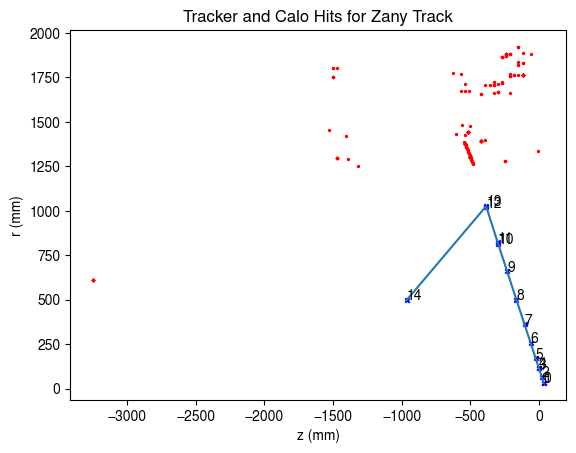

In [63]:
# Plot tracker hits
plt.scatter(zany_hits.z, zany_hits.r, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.z, hit.r, str(i), fontsize=10)
plt.plot(zany_hits.z, zany_hits.r)

# Plot calo hits
plt.scatter(zany_calo_hits.z, zany_calo_hits.r, s=2, color='red')

plt.xlabel('z (mm)')
plt.ylabel('r (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

In [64]:
zany_daughters = particles.iloc[daughters.iloc[zany_particle.daughters_begin:zany_particle.daughters_end].particle_id.values]
zany_daughters.sort_values(by='time', inplace=True)
zany_daughters.reset_index(drop=True, inplace=True)

zany_daughters

/tmp/ipykernel_178256/1061023566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zany_daughters.sort_values(by='time', inplace=True)


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,11,0,1426063360,-1.0,2.645339,0.000511,-687.351503,-1197.172228,-535.564515,0.002984,...,0.350276,1380.461311,1379.128976,0.004034,0.003523,7,True,False,False,False
1,11,0,1426063360,-1.0,3.147637,0.000511,-779.604915,-1241.507414,-502.673561,0.002282,...,1.159005,1465.989250,1464.019664,0.006214,0.005703,1,True,False,False,False
2,11,0,1426063360,-1.0,4.048322,0.000511,-741.925379,-1238.958338,-579.806645,-0.000770,...,-2.235586,1444.116003,1444.571665,0.001610,0.001099,22,True,False,False,False
3,2112,0,1426063360,0.0,6.554872,0.939565,-807.696333,-1455.213187,-255.898275,0.028788,...,0.091338,1664.337341,1735.642041,0.941158,0.001592,3,True,False,False,False
4,11,0,1426063360,-1.0,11.044002,0.000511,-1090.969907,-1305.838405,-962.932832,-0.049356,...,-1.774378,1701.596097,1745.846798,0.244135,0.243624,2,True,False,False,False
5,2112,0,1409286144,0.0,13.800005,0.939565,-998.920146,-1415.776148,-250.977424,-0.015189,...,-2.435677,1732.704117,1826.655213,0.940674,0.001108,6,True,False,False,False
6,2112,0,1426063360,0.0,21.554548,0.939565,1264.423457,-322.810716,-1419.361752,-0.019083,...,2.045308,1304.980244,1281.259954,0.940643,0.001078,2,True,False,False,False
7,2212,0,1493172224,1.0,42.767178,0.938272,995.311986,-410.936296,-1164.750212,0.009003,...,-1.296719,1076.807591,1076.816106,0.939313,0.001041,0,True,True,True,False
8,2212,0,1493172224,1.0,91.484825,0.938272,46.514802,-492.854536,-977.543105,-0.036157,...,3.134015,495.044665,495.033450,0.939545,0.001273,0,True,True,True,False
9,2212,0,1493172224,1.0,101.259247,0.938272,-238.007423,-994.740859,-1904.662092,-0.031932,...,-2.417372,1022.818121,1022.835091,0.939379,0.001107,0,True,True,True,False


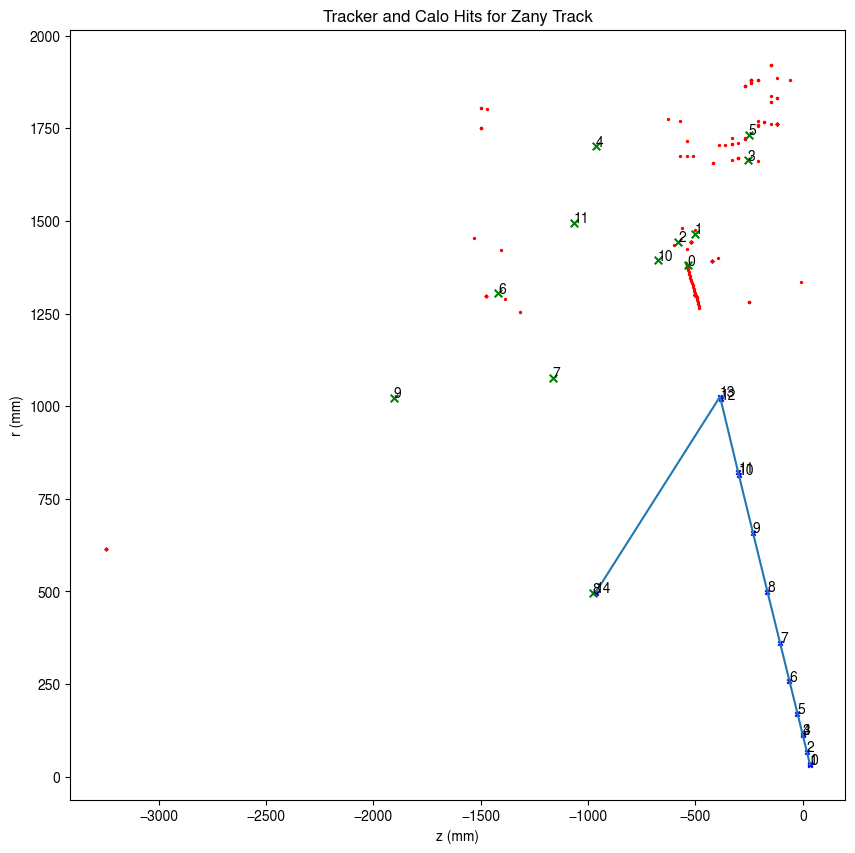

In [69]:
plt.figure(figsize=(10, 10))
# Plot tracker hits
plt.scatter(zany_hits.z, zany_hits.r, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.z, hit.r, str(i), fontsize=10)
plt.plot(zany_hits.z, zany_hits.r)

# Plot calo hits
plt.scatter(zany_calo_hits.z, zany_calo_hits.r, s=2, color='red')

# Plot daughters
plt.scatter(zany_daughters.vz, zany_daughters.vr, s=30, marker="x", color='green')

for i, daughter in zany_daughters.iterrows():
    plt.text(daughter.vz, daughter.vr, str(i), fontsize=10)

plt.xlabel('z (mm)')
plt.ylabel('r (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

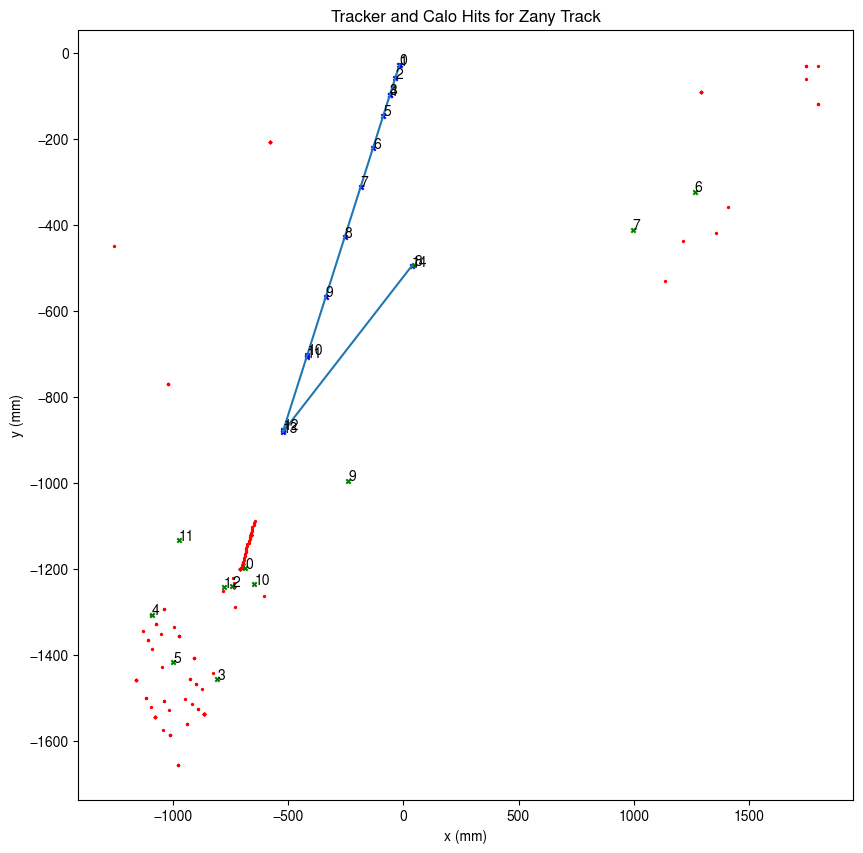

In [66]:
plt.figure(figsize=(10, 10))
# Plot tracker hits
plt.scatter(zany_hits.x, zany_hits.y, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.x, hit.y, str(i), fontsize=10)
plt.plot(zany_hits.x, zany_hits.y)

# Plot calo hits
plt.scatter(zany_calo_hits.x, zany_calo_hits.y, s=2, color='red')

# Plot daughters
plt.scatter(zany_daughters.vx, zany_daughters.vy, s=10, marker="x", color='green')

for i, daughter in zany_daughters.iterrows():
    plt.text(daughter.vx, daughter.vy, str(i), fontsize=10)

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

## Zany 29032

In [22]:
zany_track_id = 29032
zany_hits = hits[hits.particle_id == zany_track_id].sort_values(by='time').reset_index(drop=True)
zany_calo_hits = calo_hits[calo_hits.particle_id == zany_track_id].sort_values(by='time').reset_index(drop=True)
zany_particle = particles.iloc[zany_track_id]

In [23]:
zany_particle

PDG                              -211
generatorStatus                     1
simulatorStatus              16777216
charge                           -1.0
time                         3.989472
mass                          0.13957
vx                           0.010815
vy                           0.009418
vz                          -16.30389
px                           -0.92899
py                          -0.544496
pz                           4.650817
endpoint_x                -655.140884
endpoint_y                -375.904266
endpoint_z                3231.448907
parents_begin                   92934
parents_end                     92935
daughters_begin                139535
daughters_end                  139565
pt                             1.0768
p                            4.773845
eta                          2.169336
phi                         -2.611445
vr                           0.014341
endpoint_r                 755.323504
energy                       4.775884
kinetic_ener

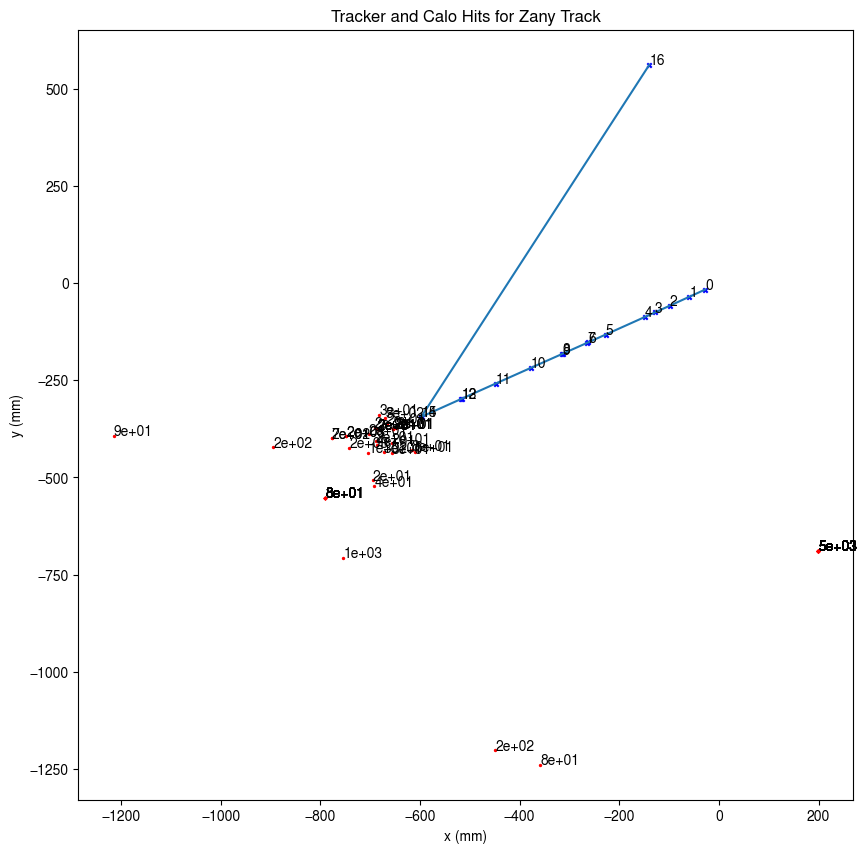

In [33]:
plt.figure(figsize=(10, 10))

# Plot tracker hits
plt.scatter(zany_hits.x, zany_hits.y, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.x, hit.y, str(i), fontsize=10)
plt.plot(zany_hits.x, zany_hits.y)

# Plot calo hits
plt.scatter(zany_calo_hits.x, zany_calo_hits.y, s=2, color='red')

for i, hit in zany_calo_hits.iterrows():
    # Only show 1 significant figure of the time
    plt.text(hit.x, hit.y, f"{hit.time:.0e}", fontsize=10)

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

In [32]:
zany_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,17868607981830,4.463311,0.553786,0,-27.581576,-16.146285,121.757874,-0.929860,-0.543205,4.649474,0.000157,29032,PixelBarrelReadout,31.960067,125.882588,-2.611977,0.256698,2.047491,1.076899
1,36969770521366,5.007535,0.562114,0,-59.382549,-34.750302,280.621533,-0.931260,-0.545072,4.645803,0.000180,29032,PixelBarrelReadout,68.803129,288.933063,-2.612131,0.240438,2.113605,1.079050
2,3300381236774,5.668872,0.553534,0,-98.102167,-57.427095,473.658562,-0.930765,-0.546737,4.642777,0.000536,29032,PixelBarrelReadout,113.674564,487.108140,-2.611992,0.235538,2.134392,1.079465
3,68451063048,6.178423,0.128326,0,-128.001552,-74.831085,622.600000,-0.931935,-0.541171,4.639622,0.000040,29032,PixelEndcapReadout,148.270323,640.011600,-2.612566,0.233792,2.141900,1.077668
4,68434285848,6.520977,0.128313,0,-148.058913,-86.445782,722.600000,-0.931576,-0.536170,4.638927,0.000045,29032,PixelEndcapReadout,171.447703,742.660808,-2.613125,0.232957,2.145510,1.074854
5,1073960868648713,7.868874,0.898968,0,-227.047503,-131.903755,1115.704418,-0.932267,-0.534047,4.612626,0.000406,29032,ShortStripBarrelReadout,262.581738,1146.187384,-2.615297,0.231144,2.153394,1.074397
6,1267015377931,8.473562,0.256683,0,-262.764378,-152.357407,1292.500000,-0.931699,-0.533358,4.612541,0.000074,29032,ShortStripEndcapReadout,303.739853,1327.710114,-2.616140,0.230814,2.154838,1.073561
7,1335734853643,8.490693,0.256678,0,-263.774333,-152.935323,1297.500000,-0.932146,-0.532657,4.612359,0.000097,29032,ShortStripEndcapReadout,304.903447,1332.843712,-2.616161,0.230805,2.154875,1.073601
8,1533303350299,9.330163,0.256692,0,-313.329040,-181.226297,1542.500000,-0.933279,-0.532124,4.611986,0.000207,29032,ShortStripEndcapReadout,361.964166,1584.400299,-2.617215,0.230490,2.156252,1.074321
9,1567663087643,9.347295,0.256685,0,-314.341097,-181.802597,1547.500000,-0.932947,-0.531793,4.611817,0.000084,29032,ShortStripEndcapReadout,363.128778,1589.534133,-2.617236,0.230485,2.156276,1.073869


In [35]:
zany_calo_hits

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector,r
0,0,0.000391,15.018232,0.0,0.0,0.0,29032,362283,-648.515564,-373.393768,3202.399902,ECalEndcapCollection,748.328369
1,0,0.000164,15.035529,0.0,0.0,0.0,29032,362284,-648.515564,-373.393768,3207.449951,ECalEndcapCollection,748.328369
2,0,0.000136,15.052807,0.0,0.0,0.0,29032,362285,-653.517517,-374.388733,3212.500000,ECalEndcapCollection,753.161377
3,0,0.000172,15.070076,0.0,0.0,0.0,29032,362286,-653.517517,-374.388733,3217.550049,ECalEndcapCollection,753.161377
4,0,0.000139,15.087346,0.0,0.0,0.0,29032,362287,-653.517517,-374.388733,3222.600098,ECalEndcapCollection,753.161377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,0,0.000011,4781.291992,0.0,0.0,0.0,29032,362291,199.318542,-688.341187,3434.699951,ECalEndcapCollection,716.618103
70,0,0.000005,4781.291992,0.0,0.0,0.0,29032,362291,199.318542,-688.341187,3434.699951,ECalEndcapCollection,716.618103
71,0,0.000004,4781.291992,0.0,0.0,0.0,29032,362291,199.318542,-688.341187,3434.699951,ECalEndcapCollection,716.618103
72,0,0.000002,4781.291992,0.0,0.0,0.0,29032,362291,199.318542,-688.341187,3434.699951,ECalEndcapCollection,716.618103


In [34]:
zany_calo_hits.time.values

array([  15.018232,   15.035529,   15.052807,   15.070076,   15.087346,
         15.104618,   15.407655,   15.40771 ,   15.407767,   15.407857,
         15.407983,   15.408172,   15.408356,   15.408509,   15.40869 ,
         15.587435,   16.3579  ,   16.699055,   17.191374,   19.33487 ,
         23.162312,   24.649923,   28.231184,   31.57157 ,   32.63777 ,
         38.91471 ,   41.549206,   59.19626 ,   75.245384,   75.2454  ,
         75.24541 ,   75.245415,   75.24543 ,   75.245445,   75.24547 ,
         75.24549 ,   75.245514,   75.24555 ,   75.24559 ,   75.24563 ,
         79.58175 ,   81.27953 ,   85.673775,  121.80816 ,  164.40337 ,
        177.24266 ,  321.89743 ,  733.93176 , 1161.1106  , 1616.499   ,
       1675.8313  , 1687.8221  , 4781.2915  , 4781.2915  , 4781.2915  ,
       4781.2915  , 4781.2915  , 4781.2915  , 4781.2915  , 4781.2915  ,
       4781.2915  , 4781.2915  , 4781.2915  , 4781.2915  , 4781.292   ,
       4781.292   , 4781.292   , 4781.292   , 4781.292   , 4781.

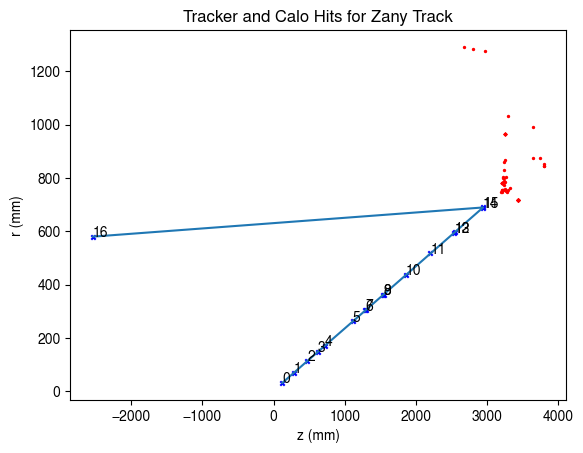

In [29]:
# Plot tracker hits
plt.scatter(zany_hits.z, zany_hits.r, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.z, hit.r, str(i), fontsize=10)
plt.plot(zany_hits.z, zany_hits.r)

# Plot calo hits
plt.scatter(zany_calo_hits.z, zany_calo_hits.r, s=2, color='red')

plt.xlabel('z (mm)')
plt.ylabel('r (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

In [41]:
daughters.iloc[zany_particle.daughters_begin:zany_particle.daughters_end].particle_id.values

array([468472, 468473, 468474, 468475, 468476, 468477, 468478, 468479,
       468480, 468481, 468482, 468483, 468484, 468485, 468488, 468499,
       468500, 468501, 468502, 468514, 468515, 468516, 468517, 468518,
       468519, 468520, 468521, 468524, 468525, 468526])

In [42]:
zany_daughters = particles.iloc[daughters.iloc[zany_particle.daughters_begin:zany_particle.daughters_end].particle_id.values]
zany_daughters.sort_values(by='time', inplace=True)
zany_daughters.reset_index(drop=True, inplace=True)

zany_daughters

/tmp/ipykernel_178256/1061023566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zany_daughters.sort_values(by='time', inplace=True)


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,11,0,1493172224,-1.0,6.987029,0.000511,-175.384411,-102.141110,858.723032,-0.001459,...,2.978888,202.959350,229.588770,0.002030,0.001519,0,True,True,True,False
1,11,0,1493172224,-1.0,7.742230,0.000511,-219.672720,-127.669839,1079.180299,0.001222,...,-0.352612,254.078122,255.716662,0.005409,0.004898,1,True,True,True,False
2,-211,0,1157627904,-1.0,15.116765,0.139570,-655.140884,-375.904266,3231.448907,0.590073,...,0.237009,755.323504,517.039480,1.350830,1.211260,102,True,False,False,False
3,211,0,1157627904,1.0,15.116765,0.139570,-655.140884,-375.904266,3231.448907,-0.060340,...,-2.086131,755.323504,1177.468757,0.381257,0.241687,25,True,False,False,False
4,2212,0,1157627904,1.0,15.116765,0.938272,-655.140884,-375.904266,3231.448907,-0.556677,...,-2.821103,755.323504,805.210400,1.108917,0.170645,1,True,False,False,False
5,-211,0,1157627904,-1.0,15.116765,0.139570,-655.140884,-375.904266,3231.448907,0.199319,...,0.278220,755.323504,743.167228,0.253839,0.114269,1,True,False,False,False
6,211,0,1157627904,1.0,15.116765,0.139570,-655.140884,-375.904266,3231.448907,-0.064955,...,3.116920,755.323504,759.232401,0.174455,0.034884,5,True,False,False,False
7,11,0,1426063360,-1.0,15.131934,0.000511,-657.278309,-375.268673,3235.412209,-0.028759,...,2.848699,756.862836,759.267086,0.061019,0.060508,2,True,False,False,False
8,-11,0,1426063360,1.0,15.131934,0.000511,-657.278309,-375.268673,3235.412209,-0.020960,...,2.886662,756.862836,761.168199,0.045696,0.045185,2,True,False,False,False
9,11,0,1426063360,-1.0,15.132444,0.000511,-655.084439,-377.408985,3235.901729,0.003299,...,-1.518382,756.024579,758.241668,0.198029,0.197518,8,True,False,False,False


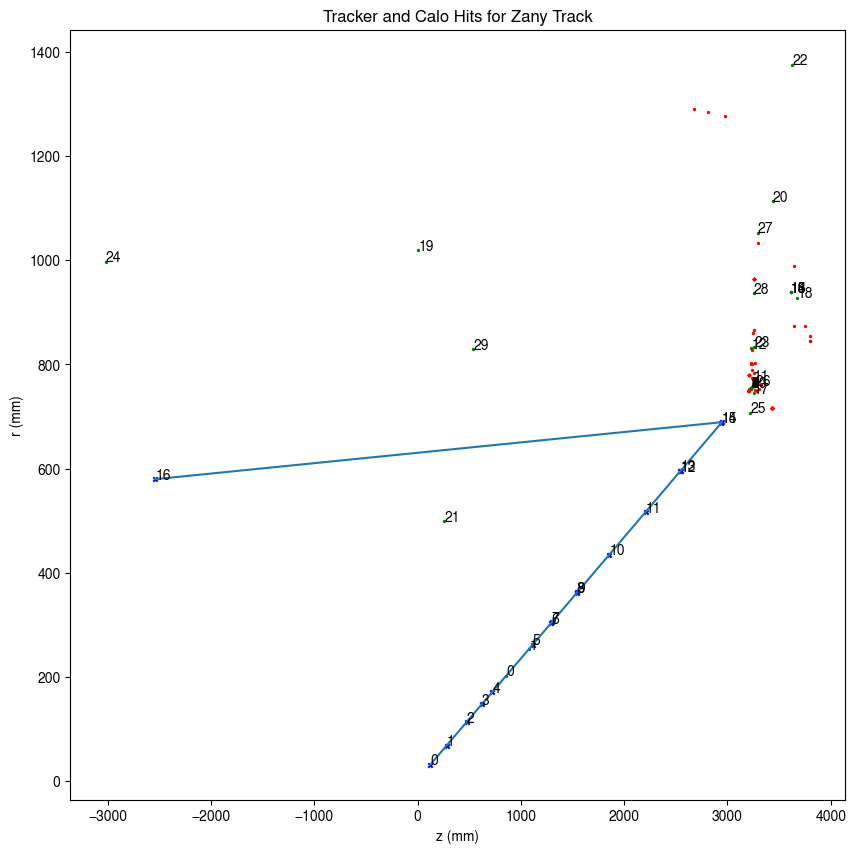

In [43]:
plt.figure(figsize=(10, 10))
# Plot tracker hits
plt.scatter(zany_hits.z, zany_hits.r, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.z, hit.r, str(i), fontsize=10)
plt.plot(zany_hits.z, zany_hits.r)

# Plot calo hits
plt.scatter(zany_calo_hits.z, zany_calo_hits.r, s=2, color='red')

# Plot daughters
plt.scatter(zany_daughters.vz, zany_daughters.vr, s=2, color='green')

for i, daughter in zany_daughters.iterrows():
    plt.text(daughter.vz, daughter.vr, str(i), fontsize=10)

plt.xlabel('z (mm)')
plt.ylabel('r (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()

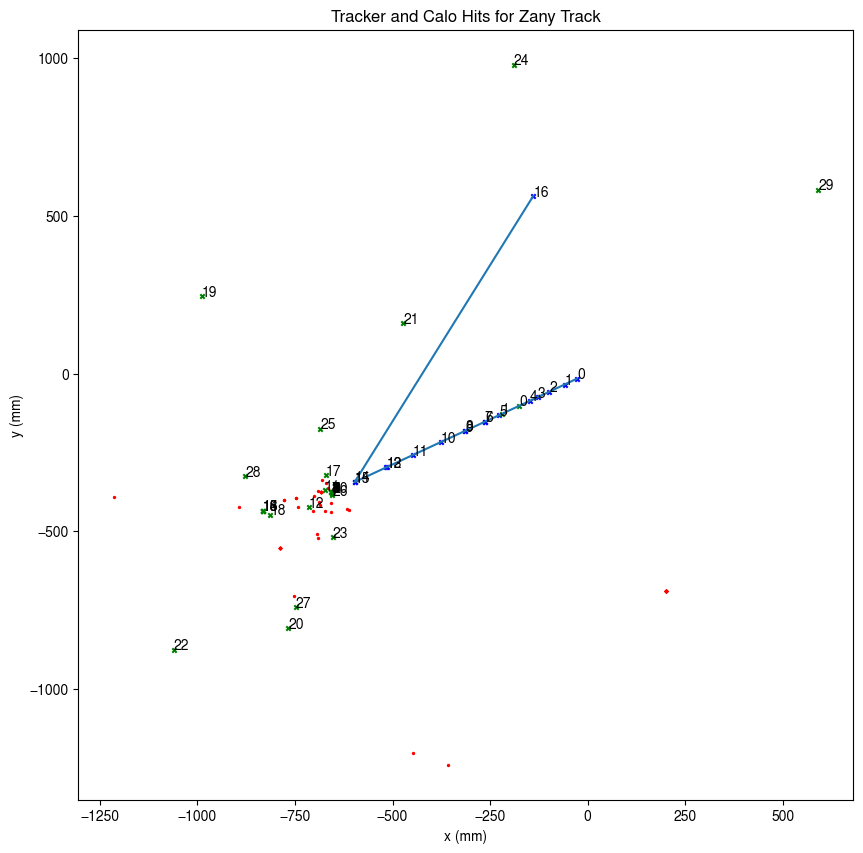

In [47]:
plt.figure(figsize=(10, 10))
# Plot tracker hits
plt.scatter(zany_hits.x, zany_hits.y, s=10, color='blue', marker="x")
# Add hit number next to each hit (0 - N)
for i, hit in zany_hits.iterrows():
    plt.text(hit.x, hit.y, str(i), fontsize=10)
plt.plot(zany_hits.x, zany_hits.y)

# Plot calo hits
plt.scatter(zany_calo_hits.x, zany_calo_hits.y, s=2, color='red')

# Plot daughters
plt.scatter(zany_daughters.vx, zany_daughters.vy, s=10, marker="x", color='green')

for i, daughter in zany_daughters.iterrows():
    plt.text(daughter.vx, daughter.vy, str(i), fontsize=10)

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Tracker and Calo Hits for Zany Track')
plt.show()